# Milestone Project B: Model Training Notebook

This notebook trains and evaluates the customer churn prediction model
for the ML microservice.

## Contents
1. Data Loading and Exploration
2. Data Preprocessing
3. Model Training with Pipelines
4. Hyperparameter Tuning
5. Model Evaluation
6. Model Serialization
7. Feature Importance Analysis

## 1. Setup and Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import warnings
from datetime import datetime
from pathlib import Path

# Scikit-learn imports
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve, precision_recall_curve
)
from sklearn.inspection import permutation_importance

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Setup complete!")

✅ Setup complete!


## 2. Load Data

In [2]:
# Load the Telco Customer Churn dataset
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nData types:\n{df.dtypes}")

df.head()

Dataset shape: (7043, 21)

Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Basic statistics
print("Dataset Overview:")
print(f"Total customers: {len(df):,}")
print(f"\nChurn distribution:")
print(df['Churn'].value_counts())
print(f"\nChurn rate: {df['Churn'].value_counts(normalize=True)['Yes']:.1%}")

print(f"\nMissing values:")
print(df.isnull().sum())

Dataset Overview:
Total customers: 7,043

Churn distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn rate: 26.5%

Missing values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


## 3. Data Preprocessing

In [4]:
# Data preprocessing function
def preprocess_data(df):
    """
    Preprocess the churn dataset.
    
    Args:
        df: Raw DataFrame
        
    Returns:
        Preprocessed DataFrame
    """
    df = df.copy()
    
    # Handle TotalCharges
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
    df['TotalCharges'] = df['TotalCharges'].fillna(0)
    
    # Drop customerID
    df = df.drop('customerID', axis=1)
    
    # Encode target
    df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
    
    return df

df_processed = preprocess_data(df)
print(f"Processed shape: {df_processed.shape}")
df_processed.head()

Processed shape: (7043, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [5]:
# Identify feature types
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_features = [col for col in df_processed.columns 
                       if col not in numeric_features + ['Churn']]

print(f"Numeric features ({len(numeric_features)}): {numeric_features}")
print(f"\nCategorical features ({len(categorical_features)}):")
for feat in categorical_features:
    print(f"  - {feat}")

Numeric features (3): ['tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features (16):
  - gender
  - SeniorCitizen
  - Partner
  - Dependents
  - PhoneService
  - MultipleLines
  - InternetService
  - OnlineSecurity
  - OnlineBackup
  - DeviceProtection
  - TechSupport
  - StreamingTV
  - StreamingMovies
  - Contract
  - PaperlessBilling
  - PaymentMethod


## 4. Train/Test Split

In [6]:
# Prepare features and target
X = df_processed.drop('Churn', axis=1)
y = df_processed['Churn']

# Stratified split: 70% train, 15% validation, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Training set: {len(X_train)} samples ({len(X_train)/len(X):.1%})")
print(f"Validation set: {len(X_val)} samples ({len(X_val)/len(X):.1%})")
print(f"Test set: {len(X_test)} samples ({len(X_test)/len(X):.1%})")

print(f"\nChurn rate - Train: {y_train.mean():.2%}, Val: {y_val.mean():.2%}, Test: {y_test.mean():.2%}")

Training set: 4930 samples (70.0%)
Validation set: 1056 samples (15.0%)
Test set: 1057 samples (15.0%)

Churn rate - Train: 26.53%, Val: 26.52%, Test: 26.58%


## 5. Build ML Pipeline

In [7]:
# Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), 
         categorical_features)
    ])

# Create full pipeline with Random Forest
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

print("Pipeline created!")
print(pipeline)

Pipeline created!
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['gender', 'SeniorCitizen',
                                                   'Partner', 'Dependents',
                                                   'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',

## 6. Hyperparameter Tuning

In [8]:
# Define parameter grid
param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [10, 20, None],
    'classifier__min_samples_split': [2, 5],
    'classifier__min_samples_leaf': [1, 2]
}

print("Hyperparameter grid:")
for param, values in param_grid.items():
    print(f"  {param}: {values}")

total_combinations = np.prod([len(v) for v in param_grid.values()])
print(f"\nTotal combinations: {total_combinations}")

Hyperparameter grid:
  classifier__n_estimators: [100, 200]
  classifier__max_depth: [10, 20, None]
  classifier__min_samples_split: [2, 5]
  classifier__min_samples_leaf: [1, 2]

Total combinations: 24


In [9]:
# Perform grid search
from sklearn.model_selection import StratifiedKFold

print("Starting Grid Search...")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid_search.fit(X_train, y_train)

print("\n✅ Grid Search Complete!")
print(f"Best CV Score (F1): {grid_search.best_score_:.4f}")
print(f"\nBest Parameters:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")

Starting Grid Search...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

✅ Grid Search Complete!
Best CV Score (F1): 0.5854

Best Parameters:
  classifier__max_depth: 10
  classifier__min_samples_leaf: 2
  classifier__min_samples_split: 5
  classifier__n_estimators: 200


## 7. Model Evaluation

In [10]:
# Get best model
best_model = grid_search.best_estimator_

# Evaluate on all sets
def evaluate_model(model, X, y, set_name):
    """Evaluate model on a dataset."""
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1]
    
    return {
        'Set': set_name,
        'Accuracy': accuracy_score(y, y_pred),
        'Precision': precision_score(y, y_pred),
        'Recall': recall_score(y, y_pred),
        'F1': f1_score(y, y_pred),
        'ROC-AUC': roc_auc_score(y, y_prob)
    }

# Evaluate
train_metrics = evaluate_model(best_model, X_train, y_train, 'Train')
val_metrics = evaluate_model(best_model, X_val, y_val, 'Validation')
test_metrics = evaluate_model(best_model, X_test, y_test, 'Test')

# Display results
results_df = pd.DataFrame([train_metrics, val_metrics, test_metrics])
print("Model Performance:")
print("=" * 70)
print(results_df.round(4).to_string(index=False))

Model Performance:
       Set  Accuracy  Precision  Recall     F1  ROC-AUC
     Train    0.8663     0.8030  0.6575 0.7230   0.9420
Validation    0.7936     0.6348  0.5214 0.5725   0.8404
      Test    0.8004     0.6733  0.4840 0.5631   0.8377


In [11]:
# Classification report on test set
y_pred_test = best_model.predict(X_test)

print("\nTest Set Classification Report:")
print("=" * 70)
print(classification_report(y_test, y_pred_test, target_names=['No Churn', 'Churn']))


Test Set Classification Report:
              precision    recall  f1-score   support

    No Churn       0.83      0.91      0.87       776
       Churn       0.67      0.48      0.56       281

    accuracy                           0.80      1057
   macro avg       0.75      0.70      0.72      1057
weighted avg       0.79      0.80      0.79      1057



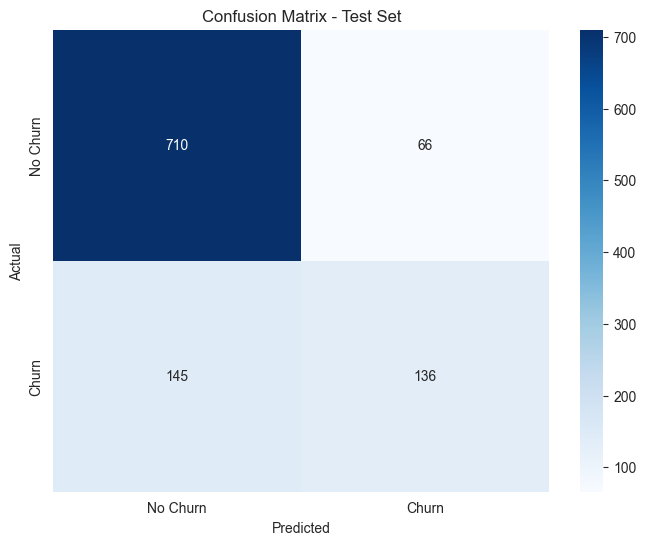

True Negatives: 710
False Positives: 66
False Negatives: 145
True Positives: 136


In [12]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix - Test Set')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print(f"True Negatives: {cm[0,0]}")
print(f"False Positives: {cm[0,1]}")
print(f"False Negatives: {cm[1,0]}")
print(f"True Positives: {cm[1,1]}")

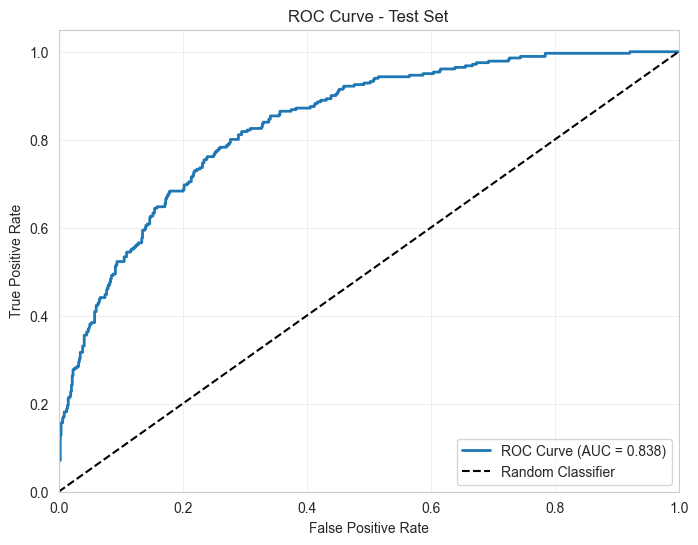

In [13]:
# ROC Curve
y_prob_test = best_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob_test)
roc_auc = roc_auc_score(y_test, y_prob_test)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Test Set')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

## 8. Feature Importance

In [ ]:
# Calculate permutation importanceprint("Calculating permutation importance...")result = permutation_importance(    best_model, X_test, y_test,    n_repeats=10,    random_state=42,    scoring='f1')    # Get feature names - permutation_importance works on original input features    # not the transformed features, so use X_test.columns    feature_names = list(X_test.columns)# Create importance DataFrameimportance_df = pd.DataFrame({    'feature': feature_names,    'importance_mean': result.importances_mean,    'importance_std': result.importances_std}).sort_values('importance_mean', ascending=False)print("\nTop 15 Most Important Features:")print(importance_df.head(15).to_string(index=False))

In [ ]:
# Plot feature importance
plt.figure(figsize=(10, 8))
top_features = importance_df.head(15)

plt.barh(range(len(top_features)), top_features['importance_mean'],
         xerr=top_features['importance_std'])
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Permutation Importance')
plt.title('Top 15 Feature Importances')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 9. Model Serialization

In [ ]:
# Create models directory
models_dir = Path('../models')
models_dir.mkdir(exist_ok=True)

# Save the complete pipeline
model_path = models_dir / 'churn_model.pkl'
joblib.dump(best_model, model_path)
print(f"✅ Model saved to {model_path}")

# Save feature names
feature_names_path = models_dir / 'feature_names.json'
with open(feature_names_path, 'w') as f:
    json.dump(X.columns.tolist(), f, indent=2)
print(f"✅ Feature names saved to {feature_names_path}")

# Save model metadata
metadata = {
    'model_type': 'RandomForestClassifier',
    'model_version': '1.0.0',
    'training_date': datetime.now().isoformat(),
    'best_params': grid_search.best_params_,
    'cv_score': float(grid_search.best_score_),
    'test_metrics': {
        'accuracy': float(test_metrics['Accuracy']),
        'precision': float(test_metrics['Precision']),
        'recall': float(test_metrics['Recall']),
        'f1': float(test_metrics['F1']),
        'roc_auc': float(test_metrics['ROC-AUC'])
    },
    'feature_count': len(X.columns),
    'training_samples': len(X_train),
    'numeric_features': numeric_features,
    'categorical_features': categorical_features
}

metadata_path = models_dir / 'model_metadata.json'
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2)
print(f"✅ Metadata saved to {metadata_path}")

In [ ]:
# Verify model can be loaded and used
loaded_model = joblib.load(model_path)

# Test prediction
sample = X_test.iloc[:5]
predictions = loaded_model.predict(sample)
probabilities = loaded_model.predict_proba(sample)[:, 1]

print("Model verification:")
for i, (pred, prob) in enumerate(zip(predictions, probabilities)):
    actual = y_test.iloc[i]
    print(f"  Sample {i+1}: Predicted={pred} (prob={prob:.3f}), Actual={actual}")

print("\n✅ Model verified successfully!")

## 10. Summary

In [ ]:
print("=" * 70)
print("MILESTONE PROJECT B - MODEL TRAINING SUMMARY")
print("=" * 70)

print(f"\n📊 Dataset:")
print(f"   • Total samples: {len(df):,}")
print(f"   • Training samples: {len(X_train):,}")
print(f"   • Test samples: {len(X_test):,}")
print(f"   • Features: {len(X.columns)}")

print(f"\n🤖 Model: Random Forest Classifier")
print(f"   • Version: 1.0.0")
print(f"   • CV F1 Score: {grid_search.best_score_:.4f}")

print(f"\n📈 Test Set Performance:")
for metric, value in test_metrics.items():
    if metric != 'Set':
        print(f"   • {metric}: {value:.4f}")

print(f"\n💾 Saved Files:")
print(f"   • {model_path}")
print(f"   • {feature_names_path}")
print(f"   • {metadata_path}")

print(f"\n🚀 Next Steps:")
print(f"   1. Copy model files to ../models/")
print(f"   2. Start the API: uvicorn api.main:app --reload")
print(f"   3. Run tests: pytest tests/")

print("\n" + "=" * 70)